# Twenty Four Seven

<div align="center">
<img src="Twenty Four Seven.png", width="30%">
<div>

The grid is incomplete. Place numbers in some of the empty cells above so that in total the grid contains one 1, two 2’s, etc., up to seven 7’s. Furthermore, each row and column must contain exactly 4 numbers which sum to 20. Finally, the numbered cells must form a connected region, but every 2-by-2 subsquare in the completed grid must contain at least one empty cell.

The answer to this puzzle is the product of the areas of the connected groups of orthogonally adjacent empty squares in the completed grid.

## Motivation

This clearly is a satisfiability problem with many different constraints. A few years ago, I recall using a solver called Z3 that performs pretty well with satisfiability problems. It was to make a Sudoku solver. I always thought it was nice to play around with it but never thought more of it. Today might be the day I use that solver again !

## Constraints 

The constraints are pretty clear and don't need more explanation than what is in the puzzle's statement. The goal here is to transcribe them into constraints the Z3 solver can read and process.

In [7]:
import z3 as z
subsquare = ((0, 0), (0, 1), (1, 0), (1, 1))
zones = [tuple((di + i, dj + j) for di, dj in subsquare) for i in range(6) for j in range(6)]

grid = [[z.Int("x%s%s" % (i, j)) for j in range(7)] for i in range(7)]
cells = [cell for row in grid for cell in row]

sum_col = [z.And(z.Sum(grid[i]) == 20) for i in range(7)]

sum_row = [z.And(z.Sum([grid[i][j] for i in range(7)]) == 20) for j in range(7)]

count_constraints = [z.PbEq([(c == i, 1) for c in cells], i) for i in range(1, 8)]

subsquares = [z.And(z.Or([grid[i][j] == 0 for i, j in zone]) for zone in zones)]

initial_state = {
    (0, 1): 4,
    (1, 2): 6, (1, 3): 3, (1, 6): 6,
    (2, 5): 5, (2, 6): 5,
    (3, 3): 4,
    (4, 0): 4, (4, 1): 7,
    (5, 0): 2, (5, 3): 7, (5, 4): 4,
    (6, 5): 1,
}

s = z.Solver()
s.add([z.And(0 <= c, c <= 7) for row in grid for c in row])
s.add([grid[i][j] == v for (i, j), v in initial_state.items()])
s.add(sum_col)
s.add(sum_row)
s.add(count_constraints)
s.add(subsquares)

if s.check() == z.sat:
	m = s.model()
	grid_answer = [[m.evaluate(grid[i][j]) for j in range(7)] for i in range(7)]
	for i in range(7):
		print([m.evaluate(grid[i][j]) for j in range(7)])

[0, 4, 0, 6, 0, 7, 3]
[0, 0, 6, 3, 5, 0, 6]
[7, 3, 0, 0, 0, 5, 5]
[0, 6, 0, 4, 5, 5, 0]
[4, 7, 7, 0, 0, 2, 0]
[2, 0, 7, 7, 4, 0, 0]
[7, 0, 0, 0, 6, 1, 6]


## Constraints based search

As you can see, with these simple constraints, we have already been able to find a feasible solution to the puzzle's problem when relaxing the connected constraint as it's the most difficult one to add with the native Z3 solver functions.

The solutions are found almost instantly and almost all the constraints are respected.

Now we need to find a way to add the connected constraint into the puzzle. Either we try to add it with the native Z3 functions, or another solution is to progressively add constraints to forbid solutions that aren't connected until we achieve one that is.

In [9]:
def nbrs(i, j):
	for a, b in ((i - 1, j), (i + 1, j), (i, j - 1), (i, j + 1)):
		if 0 <= a < 7 and 0 <= b < 7:
			yield a, b

def get_connected_components(m, g, N):
    filled = {(i, j) for i in range(N) for j in range(N)
              if m.evaluate(g[i][j]).as_long() != 0}
    seen, comps = set(), []
    for start in filled:
        if start in seen:
            continue
        comp, stack = set(), [start]
        seen.add(start)
        while stack:
            i, j = stack.pop()
            comp.add((i, j))
            for a, b in nbrs(i, j):
                if (a, b) in filled and (a, b) not in seen:
                    seen.add((a, b))
                    stack.append((a, b))
        comps.append(comp)
    return comps

def border(comp, N):
    return {(a, b) for (i, j) in comp for a, b in nbrs(i, j)} - comp

In [11]:
while True:
    if s.check() != z.sat: break
    m = s.model()
    comps = get_connected_components(m, grid, 7)
    if len(comps) == 1: break
    smallest = min(comps, key=len)
    s.add(z.Or([grid[i][j] == 0 for i, j in smallest] +
                [grid[a][b] != 0 for a, b in border(smallest, 7)]))

In [32]:
import matplotlib.pyplot as plt
###################################################################
######################### Made by AI ##############################
###################################################################
def visualize_solution(solution, empty="#e8e8e8", filled="#a8d8ea", path=None):
    N = len(solution)
    fig, ax = plt.subplots(figsize=(N * 0.7, N * 0.7))

    for i in range(N):
        for j in range(N):
            v = solution[i][j]
            ax.add_patch(plt.Rectangle((j, N - 1 - i), 1, 1,
                                       facecolor=empty if v == 0 else filled,
                                       edgecolor="black", linewidth=1))
            if v != 0:
                ax.text(j + 0.5, N - 1 - i + 0.5, str(v),
                        ha="center", va="center", fontsize=14)

    ax.set_xlim(0, N); ax.set_ylim(0, N)
    ax.set_aspect("equal"); ax.axis("off")
    if path:
        fig.savefig(path, bbox_inches="tight", dpi=150)

[7, 4, 3, 0, 6, 0, 0]
[0, 0, 6, 3, 5, 0, 6]
[0, 0, 5, 0, 5, 5, 5]
[0, 3, 6, 4, 0, 0, 7]
[4, 7, 0, 0, 0, 7, 2]
[2, 0, 0, 7, 4, 7, 0]
[7, 6, 0, 6, 0, 1, 0]
Sum of row 0: 20
Sum of col 0: 20
Sum of row 1: 20
Sum of col 1: 20
Sum of row 2: 20
Sum of col 2: 20
Sum of row 3: 20
Sum of col 3: 20
Sum of row 4: 20
Sum of col 4: 20
Sum of row 5: 20
Sum of col 5: 20
Sum of row 6: 20
Sum of col 6: 20
Counts: Counter({0: 21, 7: 7, 6: 6, 5: 5, 4: 4, 3: 3, 2: 2, 1: 1})


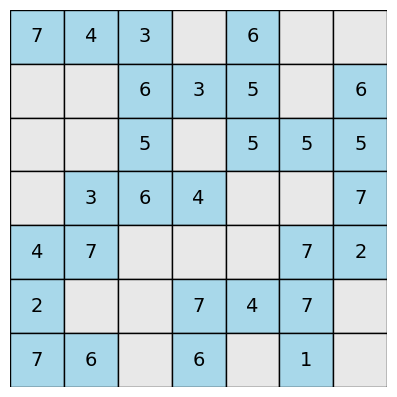

In [33]:
from collections import Counter

for i in range(7):
	print([m.evaluate(grid[i][j]) for j in range(7)])
for i in range(7):
	print("Sum of row %s: %s" % (i, sum(m.evaluate(grid[i][j]).as_long() for j in range(7))))
	print("Sum of col %s: %s" % (i, sum(m.evaluate(grid[j][i]).as_long() for j in range(7))))
counts = Counter(m.evaluate(grid[i][j]).as_long() for i in range(7) for j in range(7))
print("Counts: %s" % counts)
visualize_solution([[m.evaluate(grid[i][j]).as_long() for j in range(7)] for i in range(7)])

# Solution found ! 

The repeated solving took less than a second thanks to very optimized constraint solver Z3. Once we have the solution, it's easy to compute the answer of the puzzle by identifying the 7 zones of empty cells.

The answer to this puzzle is : 5 x 1 x 1 x 3 x 8 x 1 x 2 = 240

# Conclusion

Given that Z3 solver specializes in constraints based problems, it felt like cheating since I just fed a solver the constraints and it spat out the answer for me. I didn't have to do any work behind it. After I finished solving the puzzle, I even noticed I forgot a constraint that enforced only 4 integers per row and per column. The solution did respect this constraint but it was never put in the constraints.

Just for the sake of the learning process, it might be interesting to try and do that "alone", meaning without solvers, just using plain algorithms and plain Python.

# Another way of solving the puzzle

This time, using plain Python I will try to find the same results. Just like solving a sudoku, it's about keeping the constraints satisfied. The initial state obviously doesn't violate the constraints. From this state, we are going to try different grids that may or may not violate the constraints. If it doesn't, we can continue and if it does, we go back and try different paths.

So my idea is simply to do a Depth First Search with backtracking when violating a constraint.

## Defining the state

Before doing anything, we need to define what we are going to work with. Obviously we are going to model the grid as a simple array of arrays, but it might be efficient to store some information outside of the grid instead of using it to calculate what we need. I am going to store the following in my state that will be a dictionary:
- "grid" : Our grid
- "counts" : The counts of each numbers considering the constraint as a list (``count[i]`` corresponds to the number of `i`s in the grid, or the remaining to place haven't decided yet)
- "row_sum" : Per row sum as a list where ``row_sum[i]`` is the sum of the `i+1`'s row
- "col_sum" : Same but with columns
- "row_count" : Per row count of non-empty/non-zero squares per row.
- "col_count" : Same but with columns
- "sub_squares" : The list of 2x2 sub-squares that need at least one empty square. Will store the number of empty squares in such sub-square and flag a non feasible solution when oone sub-square is 0. Will be modeled by a list of list of shape (6, 6)